# Process-level parallelism over frames (Linux only)

`parallel_scaling.ipynb` showed that the engine's worker *threads* give almost no speed-up, and attributed
this to the interpreter lock: each node's work is dominated by Python-level overhead, and only one thread
can run Python at a time. This notebook tests that explanation directly.

In direct correlation, every frame is correlated against the same reference independently. The frames of a
sequence can therefore be divided among worker *processes*, each running the unmodified engine on its share.
Each process has its own interpreter and its own lock, so if the lock is the bottleneck, processes should
scale with the number of cores where threads did not.

This is a **prototype outside the engine**: the engine is not changed, and the approach applies only to
direct correlation, since in incremental correlation each frame depends on the previous one.

**Linux only.** Workers are started with `fork`, so they inherit the images and the configuration from this
kernel without copying them through a pipe, and the worker function can be defined in the notebook. On
Windows and macOS the default start method is `spawn`, which cannot import functions defined in a notebook.
Python 3.12 may warn that forking a multi-threaded process can deadlock; the Jupyter kernel runs a few
service threads, and the warning can be ignored for this test.

In [1]:
import os

# One thread per process for the numerical libraries, set before they are imported: otherwise every
# process would start its own BLAS/OpenMP thread pool and the processes would compete for the cores.
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[var] = "1"

import dataclasses
import multiprocessing as mp
import platform
import resource
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

cv2.setNumThreads(1)   # OpenCV's own thread pool is not fork-safe; keep it single-threaded

assert sys.platform.startswith("linux"), "this notebook relies on the fork start method (Linux only)"

REPO = Path.cwd().parent if Path.cwd().name == "benchmarks" else Path.cwd()
sys.path.insert(0, str(REPO / "examples"))

import icorrvision as ic
from synthetic import affine_warp, speckle, translate

RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser() / "parallel"
RESULTS.mkdir(parents=True, exist_ok=True)

## Machine

The distribution is read from `/etc/os-release`; `platform.release()` gives only the kernel version.

In [2]:
def cpu_name() -> str:
    for line in Path("/proc/cpuinfo").read_text().splitlines():
        if line.startswith("model name"):
            return line.split(":", 1)[1].strip()
    return platform.processor() or "unknown"


def distribution() -> str:
    try:
        fields = dict(line.split("=", 1) for line in Path("/etc/os-release").read_text().splitlines() if "=" in line)
        return fields.get("PRETTY_NAME", "unknown").strip('"')
    except OSError:
        return "unknown"


machine = {
    "cpu": cpu_name(),
    "logical_cores": os.cpu_count(),
    "distribution": distribution(),
    "kernel": platform.release(),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "opencv": cv2.__version__,
    "icorrvision": ic.__version__,
}
for k, v in machine.items():
    print(f"{k:14s} {v}")

cpu            AMD Ryzen 9 5900X 12-Core Processor
logical_cores  24
distribution   NixOS 26.11 (Zokor)
kernel         7.2.4
python         3.12.13
numpy          2.5.3
scipy          1.18.1
opencv         5.0.0
icorrvision    2.0.0


## The workload

The same frame size and configuration as `parallel_scaling.ipynb` (600 × 600 pixels, subset 21, step 6,
9409 nodes per frame), but with twelve frames so that there is work to divide. The process counts are
divisors of twelve, so every process receives the same number of frames and the comparison is not
distorted by an uneven split. Inside each process the engine uses a single worker thread.

In [3]:
SIZE, STEP, SUBSET, N_FRAMES = 600, 6, 21, 12
PROCESSES = [1, 2, 3, 4, 6, 12]
REPEATS = 3

REFERENCE = speckle(SIZE, SIZE, seed=11)
FRAMES = {}
for k in range(1, N_FRAMES + 1):
    stretched = affine_warp(REFERENCE, 0.001 * k, -0.0003 * k, 0.0)
    FRAMES[f"frame_{k:02d}"] = translate(stretched, dx=0.07 * k, dy=-0.04 * k)
NAMES = list(FRAMES)

SETUP = ic.SetupOutput(
    reference_frame=REFERENCE,
    roi_mask=np.ones(REFERENCE.shape, dtype=bool),
    subset_size=SUBSET,
    step_size=STEP,
    deformed_list=NAMES,
)
CONFIG = ic.CorrelationConfig(search_size=SUBSET + 10, n_workers=1)


def correlate(names):
    # Runs in a worker process. REFERENCE, FRAMES, SETUP and CONFIG are inherited from the kernel by fork.
    setup = dataclasses.replace(SETUP, deformed_list=list(names))
    result = ic.build_engine(CONFIG, setup, FRAMES.__getitem__).run()
    return [(f.frame_name, f.u_px, f.v_px, f.valid_mask, f.strain.exx, f.strain.eyy, f.strain.exy)
            for f in result.frames[1:]]


def chunks(names, n):
    size = len(names) // n
    return [names[i * size:(i + 1) * size] for i in range(n)]

## Serial baseline

The whole sequence in this kernel, in a single process with a single thread. This is both the reference for
the determinism check and the baseline for the speed-up.

In [4]:
baseline_times = []
for _ in range(REPEATS):
    start = time.perf_counter()
    baseline = correlate(NAMES)
    baseline_times.append(time.perf_counter() - start)
T_SERIAL = float(np.median(baseline_times))
reference_fields = {entry[0]: entry[1:] for entry in baseline}
print(f"serial: {T_SERIAL:.1f} s for {N_FRAMES} frames ({T_SERIAL / N_FRAMES:.2f} s per frame)")

serial: 88.2 s for 12 frames (7.35 s per frame)


## Processes

For each process count, the frames are split into equal contiguous chunks and correlated in a pool of
forked processes. The time is the wall-clock time of the whole sequence, including starting the processes
and returning the results: the time a user waits. Every returned field is compared
with the serial result and must be identical.

The peak resident memory of the largest worker process is also recorded (`ru_maxrss` of the children),
since each process holds its own copy of whatever it modifies.

In [5]:
FIELD_NAMES = ("u_px", "v_px", "valid_mask", "exx", "eyy", "exy")


def identical(entries) -> bool:
    for name, *fields in entries:
        for label, a, b in zip(FIELD_NAMES, fields, reference_fields[name]):
            if not np.array_equal(a, b, equal_nan=label != "valid_mask"):
                return False
    return True


context = mp.get_context("fork")
rows = []
for n in PROCESSES:
    times, same = [], True
    for _ in range(REPEATS):
        start = time.perf_counter()
        with ProcessPoolExecutor(max_workers=n, mp_context=context) as pool:
            entries = [entry for part in pool.map(correlate, chunks(NAMES, n)) for entry in part]
        times.append(time.perf_counter() - start)
        same &= identical(entries) and len(entries) == N_FRAMES
    rows.append({"processes": n, "seconds": float(np.median(times)), "spread_s": float(np.ptp(times)),
                 "identical_to_serial": same})

peak_child_MB = resource.getrusage(resource.RUSAGE_CHILDREN).ru_maxrss / 1024   # kB on Linux
scaling = pd.DataFrame(rows)
scaling["speed_up"] = T_SERIAL / scaling.seconds
scaling["efficiency"] = scaling.speed_up / scaling.processes
print(f"peak resident memory of the largest worker process: {peak_child_MB:.0f} MB")
assert scaling.identical_to_serial.all(), "process results differ from the serial result"
scaling.round(3)

peak resident memory of the largest worker process: 204 MB


,processes,seconds,spread_s,identical_to_serial,speed_up,efficiency
0,1,87.539,0.324,True,1.007,1.007
1,2,44.704,0.326,True,1.972,0.986
2,3,30.566,0.151,True,2.884,0.961
3,4,23.361,0.249,True,3.774,0.943
4,6,15.961,0.045,True,5.523,0.921
5,12,9.214,0.122,True,9.567,0.797


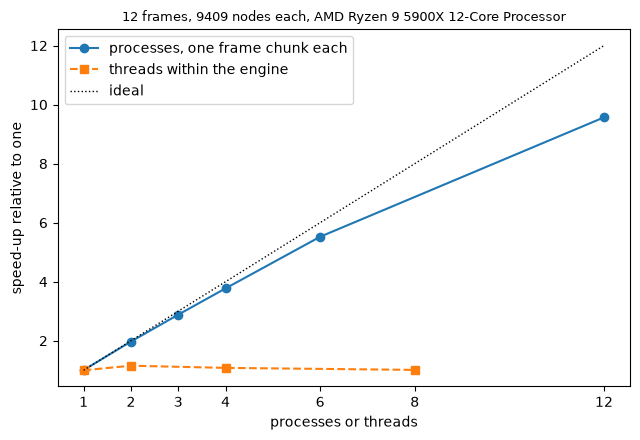

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(scaling.processes, scaling.speed_up, "o-", label="processes, one frame chunk each")
threads = RESULTS / "parallel_scaling.csv"
if threads.exists():   # the thread results of parallel_scaling.ipynb, for comparison
    t = pd.read_csv(threads)
    ax.plot(t.workers, t.speed_up, "s--", label="threads within the engine")
top = max(PROCESSES)
ax.plot([1, top], [1, top], "k:", lw=1, label="ideal")
ax.set_xlabel("processes or threads")
ax.set_ylabel("speed-up relative to one")
ax.set_xticks(sorted(set(PROCESSES) | {8}))
ax.legend()
ax.set_title(f"{N_FRAMES} frames, 9409 nodes each, {machine['cpu']}", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "process_scaling.pdf")

## Reading the result

- **Identical results** are required, as for threads. The processes run exactly the same code on exactly the
  same inputs, so any difference would point to hidden shared state.
- **Speed-up.** If the interpreter lock was the bottleneck, the speed-up should rise with the number of
  processes, well above the 1.16 obtained with threads, and fall short of ideal mainly because of process
  start-up, the transfer of the results, and each process recomputing the reference frame and the grid.
  Twelve processes on twelve physical cores also share memory bandwidth and caches, and hardware threads
  beyond the physical cores would add little.
- **Memory** grows roughly in proportion to the number of processes, since each keeps its own working set;
  the cost of avoiding the lock.

In [7]:
scaling.to_csv(RESULTS / "process_scaling.csv", index=False)
pd.Series({**machine, "serial_seconds": T_SERIAL, "peak_child_MB": peak_child_MB}).to_csv(
    RESULTS / "process_machine.csv", header=["value"])
for f in ("process_scaling.csv", "process_machine.csv", "process_scaling.pdf"):
    print("wrote", RESULTS / f)